In [ ]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()

In [36]:
def simulate_ARCH(x,n,alpha0,alpha1):
    if alpha0<=0 or alpha1<0:
        raise ValueError("Attention, ces conditions rendent la variance soit négative, soit elle divergera")
    z=rng.standard_normal(n)
    sigma_carre=alpha0+alpha1*(x**2)

    resultats=[0]*(n+1)
    resultats[0]=x

    vol=[0]*(n+1)
    vol[0]=sigma_carre

    for k in range(0,n):
        x=z[k]*np.sqrt(sigma_carre)
        sigma_carre=alpha0+alpha1*(x**2)
        resultats[k+1]=x
        vol[k+1]=sigma_carre
    return resultats,vol


In [41]:
x,vol=simulate_ARCH(0,500,1,0.5)

In [38]:
print(f'Les premières réalisations de X sont {x[0]:.2f},{x[1]:.2f},{x[2]:.2f},{x[3]:.2f},{x[4]:.2f}')
print(f'Les premières réalisations de sigma_carre sont {vol[0]:.2f},{vol[1]:.2f},{vol[2]:.2f},{vol[3]:.2f},{vol[4]:.2f}')

Les premières réalisations de X sont 0.00,-0.57,-0.67,1.47,0.48
Les premières réalisations de sigma_carre sont 1.00,1.16,1.23,2.08,1.11


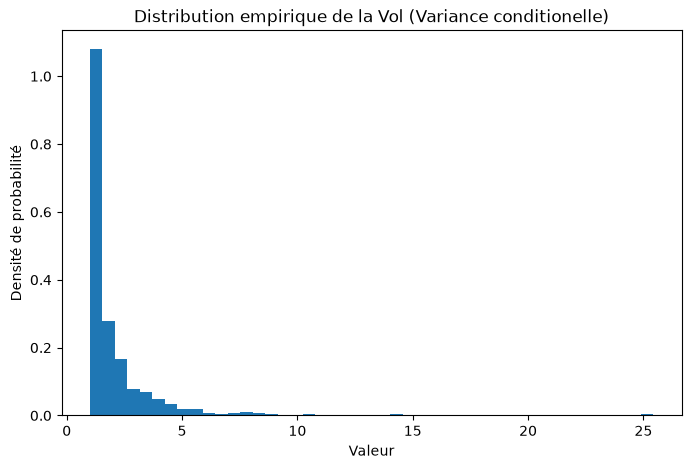

In [39]:
plt.figure(figsize=(8, 5))
plt.hist(vol,bins='auto',density=True)
plt.title('Distribution empirique de la Vol (Variance conditionelle)')
plt.xlabel('Valeur')
plt.ylabel('Densité de probabilité')
plt.show()

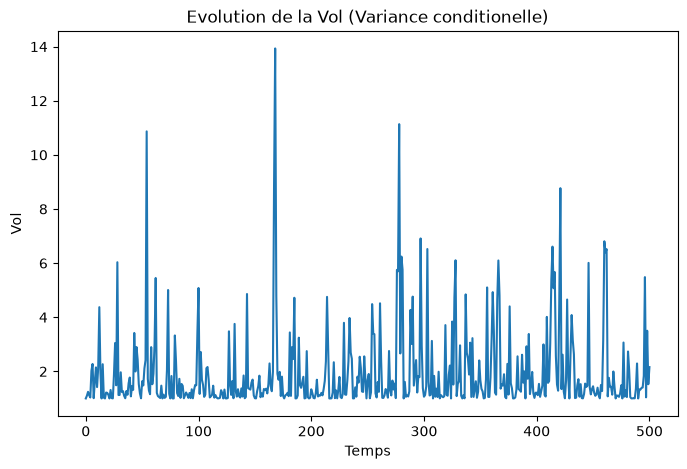

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(vol)
plt.title('Evolution de la Vol (Variance conditionelle)')
plt.xlabel('Temps')
plt.ylabel('Vol')
plt.show()

In [139]:
from numpy.polynomial import Polynomial
from scipy.linalg import toeplitz
from statsmodels.tsa.arima_process import ArmaProcess

#Let's try to simulate a AR process (with random coefficients) and a white noise that follows normal law (0,sigma)
#Let's begin by considering without a constant
def AR(p,sigma,n):
    racines=1/rng.uniform(-1,1,p) #We first begin to create random roots

    P_unitaire = Polynomial.fromroots(racines) #We create our polynome using our roots (unitary polynome)
    P_final=P_unitaire

    coefficients = P_final.coef #Ce ne sont pas les phi attention (mais - phi)
    ar = P_final.coef / P_final.coef[0] #On force le polynome à être unitaire

    ma = np.array([1]) #On crée un MA constant (juste pour mettre l'argument dans ARMA Process)

    processus = ArmaProcess(ar,ma)

    gamma = processus.acovf(nobs=p) * (sigma) #Notre vecteur d'auto covariance
    matrice_covariance = toeplitz(gamma[:p]) # Matrice de covariance à l'aide de Toeplitz
    
    mean = np.zeros(p) 

    init=rng.multivariate_normal(mean,matrice_covariance)
    evo=[0]*n

    total = np.concatenate([init, evo])

    phis=-ar[1:] #On enlève la constante
    phis=phis[::-1] #On met dans l'ordre inverse


    for k in range(p,len(total)):
        bruit=rng.normal(0,sigma**2)
        x0=phis@total[k-p:k]+bruit
        total[k]=x0
    
    plt.figure(figsize=(8, 5))
    plt.plot(total)
    plt.title(f'AR({p}) sur {n+p} périodes et un écart-type {sigma}')
    plt.xlabel('Temps')
    plt.ylabel('Xt')
    plt.show()
    print('racines inverses : ',racines)

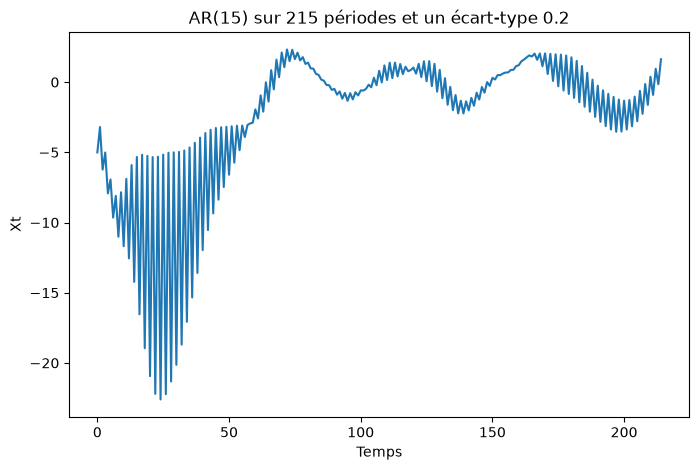

racines inverses :  [ 1.05950888 -1.4114852  -1.97039069  1.15622113  3.82763851 -1.08236596
 -1.18299516  1.75167817  7.41020699  7.64345057  1.31625486 -1.93123207
 -1.47245471  4.39344349  1.30745241]


In [161]:
AR(15,0.2,200)